# 📌 Titolo del progetto

**Simulazione dell’algoritmo PageRank mediante catene di Markov su un grafo ipertestuale**

## 🎯 Obiettivo del progetto

L’obiettivo di questo progetto è modellare la navigazione di un utente all’interno di un insieme di pagine web rappresentate da un **grafo orientato** (ipertestuale) utilizzando una **catena di Markov**.

Nello specifico, il progetto mira a:

- implementare una **simulazione** in cui un utente si sposta casualmente da una pagina all’altra seguendo i collegamenti (link) disponibili;
- rappresentare questo comportamento attraverso una **matrice di transizione stocastica**;
- studiare l’**evoluzione della distribuzione di probabilità** delle visite alle pagine nel tempo;
- verificare **sperimentalmente** che tale distribuzione converge verso una **distribuzione stazionaria (invariante)**;
- interpretare questa distribuzione limite come una stima del **PageRank**, ovvero una misura dell’importanza relativa delle pagine all’interno del grafo.
## 🧰 Strumenti utilizzati

- **Python** — linguaggio di programmazione
- **NumPy** — simulazione e calcolo numerico
- **Pandas** — organizzazione dei risultati
- **Matplotlib** — visualizzazione grafica
- **SciPy** — intervalli di confidenza e distribuzione t di Student

## 📂 Struttura del notebook

1. Definizione del grafo e della matrice di transizione
2. Simulazione della passeggiata aleatoria
3. Analisi statistica della frequenza di visita alla pagina 2
4. Intervalli di confidenza
5. Teorema Limite Centrale

In [ ]:
 #Importazione delle librerie

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as spy
import networkx as nx

## 1. 🔗 Simulazione della Catena di Markov

In questa parte si simula il percorso di un utente che naviga tra le pagine di un grafo ipertestuale composto da **6 pagine web**.

- Si parte da una pagina scelta **uniformemente a caso** tra le 6 pagine
- Ad ogni passo, l'utente si sposta secondo le probabilità della **matrice di transizione P**
- Il processo viene ripetuto per un numero fissato di passi

### 🎯 Obiettivo
Generare una **traiettoria** (sequenza di pagine visitate) che rappresenta il percorso dell'utente nel grafo, sfruttando la **proprietà di Markov** : lo stato successivo dipende solo dallo stato corrente.

In [ ]:
# Matrice di transizione

P=np.array([
    [0,0.23,0,0.77,0,0],
    [0.09,0,0.06,0,0,0.85],
    [0,0,0,0.63,0,0.37],
    [0,0,0,0,0.65,0.35],
    [0,0,0,0,0,1],
    [0,0.62,0,0,0.38,0]
])

df=pd.DataFrame(P,index=[1,2,3,4,5,6],columns=[1,2,3,4,5,6])
df


,1,2,3,4,5,6
1,0.00,0.23,0.00,0.77,0.00,0.00
2,0.09,0.00,0.06,0.00,0.00,0.85
3,0.00,0.00,0.00,0.63,0.00,0.37
4,0.00,0.00,0.00,0.00,0.65,0.35
5,0.00,0.00,0.00,0.00,0.00,1.00
6,0.00,0.62,0.00,0.00,0.38,0.00


[2, 6, 5, 6, 2, 6, 2, 6, 5, 6, 2, 6, 5, 6, 5, 6, 2, 6, 5, 6, 2, 6, 2, 3, 4, 6, 5, 6, 2, 6, 5, 6, 2, 6, 5, 6, 2, 6, 2, 6, 2, 6, 2, 6, 2, 1, 4, 5, 6, 2, 6, 5, 6, 2, 6, 2, 6, 2, 6, 5, 6, 5, 6, 2, 6, 2, 6, 2, 6, 5, 6, 5, 6, 2, 6, 2, 6, 5, 6, 2, 6, 2, 3, 4, 5, 6, 5, 6, 2, 6, 2, 6, 5, 6, 2, 1, 4, 6, 2, 6, 5]


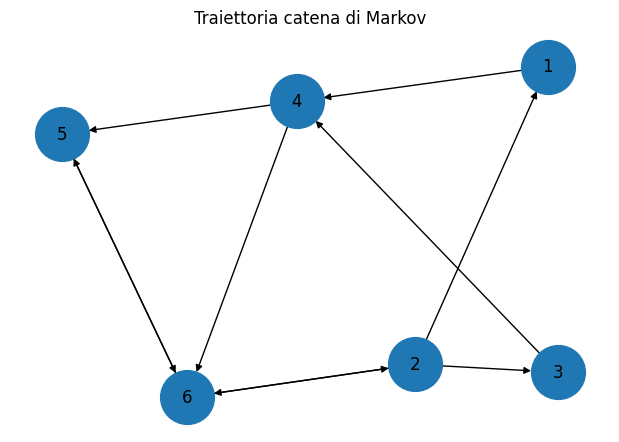

In [ ]:
# Generazione di una passeggiata aleatoria
import numpy as np

rng = np.random.default_rng()  # globale

def traiettoria(Matrice, n_passi, partenza):
    stato_attuale = partenza
    cammino = [stato_attuale]

    for i in range(n_passi):
        stato_successivo = rng.choice(6, p=Matrice[stato_attuale])
        cammino.append(stato_successivo)
        stato_attuale = stato_successivo

    return [s + 1 for s in cammino]
cammino_pagine=traiettoria(P,100,1)
print(cammino_pagine)






# Costrizione del grafico della passeggiata
edges = [(cammino_pagine[i], cammino_pagine[i+1]) for i in range(len(cammino_pagine)-1)]

G = nx.DiGraph()
G.add_edges_from(edges)

plt.figure(figsize=(6,4))
pos = nx.spring_layout(G)

nx.draw(G, pos, with_labels=True, node_size=1500, arrows=True)
plt.title("Traiettoria catena di Markov")
plt.show()

### 📊 Osservazione
All'aumento del numero di passi, la traiettoria include un numero crescente di **nodi distinti** visitati.
Con pochi passi l'utente esplora solo le pagine vicine al punto di partenza, mentre con molti passi tende a raggiungere **tutte le pagine del grafo**.

Questo è possibile perché la catena è **irriducibile** : esiste sempre un percorso da qualsiasi pagina a qualsiasi altra.
Di conseguenza, a lungo termine, la distribuzione delle visite converge verso una **distribuzione stazionaria π**, indipendentemente dalla pagina di partenza.



## 2. 📊 Raccolta delle statistiche e distribuzione delle frequenze

In questa parte si analizza la **distribuzione delle visite** alle pagine web durante la navigazione.

### 🔁 Principio

Per ogni pagina di partenza (1 → 6), si simula una traiettoria di **N passi** e si calcola la frequenza relativa di visita per ciascuna pagina :

$$f_i = \frac{\text{numero di visite alla pagina } i}{\text{numero totale di passi}}$$

### 🎯 Obiettivo

- Stimare la **frequenza di visita** per ciascuna delle 6 pagine
- Verificare che, dopo un numero sufficiente di passi, la distribuzione converge verso la **distribuzione invariante**, indipendentemente dalla pagina di partenza



In [ ]:
# Stima delle frequenze di visite di ogni pagina.
# Fissiamo una pagine initial e un nmero di passi

def frequenze_visite_per_pagina(n_passo, Matrice, partenza):
    stato_attuale = partenza
    frequenze = {0:0, 1:0, 2:0, 3:0, 4:0, 5:0}

    for i in range(n_passo):
        frequenze[stato_attuale] += 1
        stato_attuale = rng.choice(6, p=Matrice[stato_attuale])

    Total = sum(frequenze.values())
    for pagina in frequenze:
        frequenze[pagina] /= Total

    df = pd.DataFrame(list(frequenze.items()), columns=["Pagina", "Frequenze"])
    df["Pagina"] = df["Pagina"] + 1
    return df

print(frequenze_visite_per_pagina(1000,P,1))

   Pagina  Frequenze
0       1      0.029
1       2      0.290
2       3      0.015
3       4      0.027
4       5      0.188
5       6      0.451


In [ ]:
# Controlla che la distribuzione delle frequenze sia indepente dalla pagina di partenza dopo alcuni passi
import numpy as np
import pandas as pd

def indipendenza_partenza(n_passo, Matrice, seed=42):
    rng = np.random.default_rng(seed)
    n_stati = Matrice.shape[0]
    cum_P = np.cumsum(Matrice, axis=1)  # sommes cumulees par ligne
    risultati = np.zeros((n_stati, n_stati))

    for j in range(n_stati):
        u = rng.random(n_passo)  # tous les tirages d'un coup
        traiettoria = np.empty(n_passo, dtype=np.int64)
        stato_attuale = j

        for i in range(n_passo):
            traiettoria[i] = stato_attuale
            stato_attuale = np.searchsorted(cum_P[stato_attuale], u[i])

        conteggi = np.bincount(traiettoria, minlength=n_stati)
        risultati[j] = conteggi / n_passo

    df = pd.DataFrame(
        risultati,
        index=[f"Partenza {i+1}" for i in range(n_stati)],
        columns=[f"Pagina {i+1}" for i in range(n_stati)]
    )
    return df

df = indipendenza_partenza(10000, P)
print(df.round(4).to_string())


            Pagina 1  Pagina 2  Pagina 3  Pagina 4  Pagina 5  Pagina 6
Partenza 1    0.0249    0.2907    0.0175    0.0302    0.1854    0.4513
Partenza 2    0.0248    0.2819    0.0175    0.0298    0.1945    0.4515
Partenza 3    0.0271    0.2814    0.0154    0.0289    0.1963    0.4509
Partenza 4    0.0258    0.2844    0.0167    0.0309    0.1919    0.4503
Partenza 5    0.0260    0.2854    0.0172    0.0326    0.1893    0.4495
Partenza 6    0.0260    0.2810    0.0161    0.0324    0.1955    0.4490


### 📊 Osservazione

Con un numero elevato di passi, le distribuzioni ottenute partendo da pagine diverse tendono a **coincidere**.
Questo conferma che la catena è **ergodica** : a lungo termine la distribuzione delle frequenze è **indipendente dalla pagina iniziale** e converge verso una distribuzione cosidetto **stationaria** .

## 3. 🛑 Terminazione della passeggiata aleatoria

In questa parte si introduce la possibilità che l'utente **abbandoni la navigazione** ad ogni passo con una probabilità `p`.

### 🔁 Principio

Ad ogni passo (incluso il passo 0), l'utente ha una probabilità `p` di fermarsi :

- Con probabilità `p` → **stop**
- Con probabilità `1-p` → continua verso la pagina successiva

La lunghezza media della traiettoria è quindi :

$$\mathbb{E}[\text{passi}] = \frac{1}{p}$$

### 🎯 Obiettivo

- Simulare **numerosi utenti** con diverse valori di `p`
- Osservare come la distribuzione delle frequenze **cambia al variare di p**



In [ ]:
def passeggiata_termina(n_passi, Matrice, p, partenza):
    stato_presente = partenza
    cammino = [stato_presente]

    for k in range(n_passi):
        if rng.random() < p:
            cammino.append("STOP")
            break
        stato_presente = rng.choice(6, p=Matrice[stato_presente])
        cammino.append(stato_presente)

    return ["STOP" if n == "STOP" else n + 1 for n in cammino]

print(passeggiata_termina(100, P, 0.01,1))

[2, 6, 2, 6, 2, 6, 2, 6, 2, 1, 4, 5, 6, 2, 6, 2, 6, 2, 6, 5, 6, 2, 6, 2, 6, 2, 6, 5, 6, 2, 6, 5, 6, 5, 6, 5, 6, 5, 6, 5, 6, 2, 6, 2, 6, 5, 6, 5, 6, 5, 6, 2, 'STOP']


## Numerosi Utente

In [ ]:
def numerosi_utenti(n_passi, Matrice, p, n_utente):
    cammino_totale = {i: 0 for i in range(6)}

    for j in range(n_utente):
        stato = rng.integers(6)
        cammino_utente = {i: 0 for i in range(6)}

        for k in range(n_passi):
            cammino_utente[stato] += 1
            if rng.random() < p:
                break
            stato = rng.choice(6, p=Matrice[stato])

        for i in cammino_totale:
            cammino_totale[i] += cammino_utente[i]

    totale = sum(cammino_totale.values())
    return {i + 1: v / totale for i, v in cammino_totale.items()}
frequenze_001=numerosi_utenti(1000,P,0.01,500)
print(frequenze_001)

{1: 0.026768397945482834, 2: 0.28179280066494744, 3: 0.018392617378146247, 4: 0.033801496131796, 5: 0.19179045629888536, 6: 0.4474542315807421}


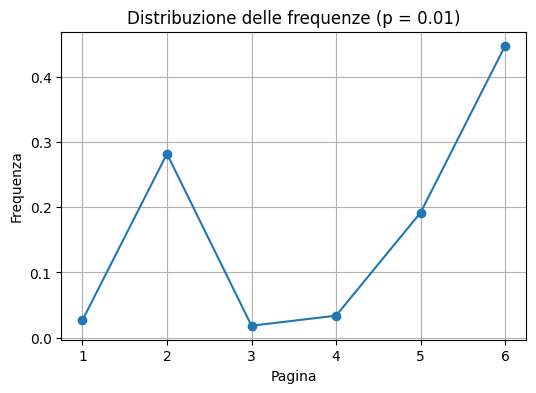

In [ ]:
#Grafico

Pagine=list(frequenze_001.keys())
freq=list(frequenze_001.values())
plt.figure(figsize=(6,4))
plt.plot(Pagine,freq,marker='o')
plt.xlabel("Pagina")
plt.ylabel("Frequenza")
plt.title("Distribuzione delle frequenze (p = 0.01)")
plt.xticks(Pagine)
plt.grid(True)
plt.show()


In [ ]:

frequenze_01=numerosi_utenti(1000,P,0.1,500)
print(frequenze_01)

{1: 0.035225859925404064, 2: 0.258184832159138, 3: 0.029216742644011605, 4: 0.05843348528802321, 5: 0.19560712805636138, 6: 0.42333195192706174}


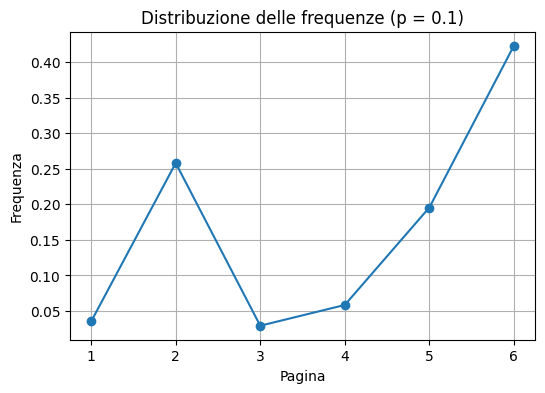

In [ ]:
#Grafico

Pagine=list(frequenze_01.keys())
freq=list(frequenze_01.values())
plt.figure(figsize=(6,4))
plt.plot(Pagine,freq,marker='o')
plt.xlabel("Pagina")
plt.ylabel("Frequenza")
plt.title("Distribuzione delle frequenze (p = 0.1)")
plt.xticks(Pagine)
plt.grid(True)
plt.show()


In [ ]:
frequenze_05=numerosi_utenti(1000,P,0.8,500)
print(frequenze_05)

{1: 0.13980263157894737, 2: 0.16940789473684212, 3: 0.15789473684210525, 4: 0.20723684210526316, 5: 0.13486842105263158, 6: 0.19078947368421054}


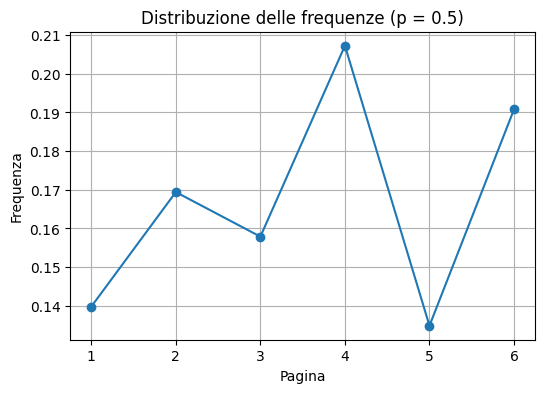

In [ ]:
#Grafico

Pagine=list(frequenze_05.keys())
freq=list(frequenze_05.values())
plt.figure(figsize=(6,4))
plt.plot(Pagine,freq,marker='o')
plt.xlabel("Pagina")
plt.ylabel("Frequenza")
plt.title("Distribuzione delle frequenze (p = 0.5)")
plt.xticks(Pagine)
plt.grid(True)
plt.show()


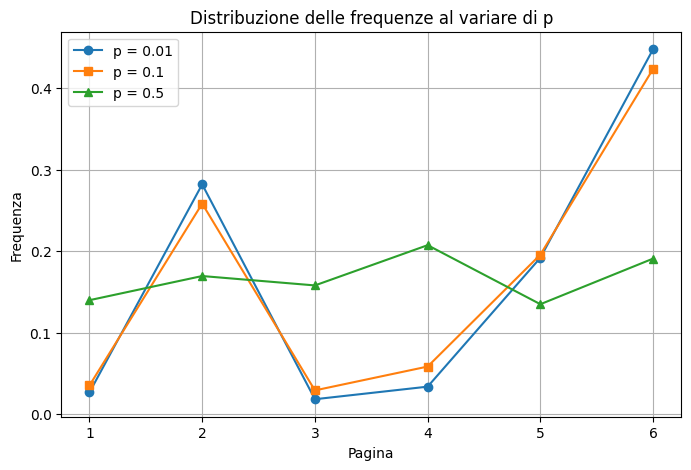

In [ ]:
import matplotlib.pyplot as plt

pagine = list(frequenze_001.keys())

plt.figure(figsize=(8,5))

plt.plot(pagine,
         list(frequenze_001.values()),
         marker='o',
         label='p = 0.01')

plt.plot(pagine,
         list(frequenze_01.values()),
         marker='s',
         label='p = 0.1')

plt.plot(pagine,
         list(frequenze_05.values()),
         marker='^',
         label='p = 0.5')

plt.xlabel("Pagina")
plt.ylabel("Frequenza")
plt.title("Distribuzione delle frequenze al variare di p")
plt.xticks(pagine)
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
print(frequenze_001)
print(frequenze_01)
print(frequenze_05)

{1: 0.08588351431391905, 2: 0.19940769990128332, 3: 0.09180651530108588, 4: 0.13524185587364265, 5: 0.1362290227048371, 6: 0.351431391905232}
{1: 0.04229091598710411, 2: 0.30874265124217715, 3: 0.029774322017826663, 4: 0.06315190593589987, 5: 0.04930779442442632, 6: 0.5067324103925659}
{1: 0.14169381107491857, 2: 0.1986970684039088, 3: 0.13192182410423453, 4: 0.15798045602605862, 5: 0.1449511400651466, 6: 0.2247557003257329}


In [ ]:
print(sum(frequenze_001.values()))
print(sum(frequenze_01.values()))
print(sum(frequenze_05.values()))

1.0
1.0
1.0


### 📊 Osservazione

- **p piccolo** (es. 0.01) → traiettoria lunga → la distribuzione converge verso **π** indipendentemente dalla pagina iniziale
- **p grande** (es. 0.8) → traiettoria corta → la distribuzione **dipende dalla pagina di partenza**
- Aumentando `p`, la distribuzione tende ad **appiattirsi** poiché l'utente non ha tempo di esplorare il grafo

## 4. 📈 Analisi statistica della frequenza di visita alla pagina 2

In questa parte si analizza statisticamente la frequenza con cui viene visitata la **pagina 2**, considerando il caso `p=0.01`.


## 4a. 🎯 Stima dell'attesa e della varianza

Si simulano **K utenti indipendenti**, ognuno con una traiettoria di massimo 1000 passi.
Per ogni utente si calcola la **frequenza relativa** di visita alla pagina 2.

$$f_i = \frac{\text{visite pagina 2}}{\text{passi totali dell'utente } i}$$

In [ ]:
# Attesa et varianza

def frequenza_pagina2(n,p,matrice,n_passi_max):

  frequenze_p2={}
  n_user=n
  M=matrice

  for user in range(n_user):
    frequenze_per_users={0:0, 1:0, 2:0, 3:0, 4:0, 5:0}
    inizio=1
    for i in range(n_passi_max):
      frequenze_per_users[inizio]+=1
      if rng.random()<p:

        break
      inizio=rng.choice(6,p=M[inizio])

    frequenze_p2["u"+str(user)]=frequenze_per_users[1]/sum(frequenze_per_users.values())
  return frequenze_p2






In [ ]:
risultati=frequenza_pagina2(n=50, p=0.01, matrice=P, n_passi_max=1000)
valori=list(risultati.values())
print(f"Valore Atteso: {np.mean(valori): .4f}")
print(f"Varianza: {np.var(valori): .4f}")

Valore Atteso:  0.3019
Varianza:  0.0062


#### 📊 Osservazione
La media e la varianza calcolate su K frequenze forniscono una stima della **frequenza attesa** di visita alla pagina 2 e della sua **variabilità** tra utenti diversi.

### 4b. 📏 Intervallo di confidenza al 95%

Si ripete la passeggiata per **K = 50, 100, 200, 2000** utenti, troncando ogni traiettoria dopo **100 passi**.
Poiché la varianza vera è sconosciuta, si utilizza la **varianza corretta** e la **distribuzione t di Student** :

$$IC = \bar{x} \pm t_{0.025,\, K-1} \cdot \frac{s}{\sqrt{K}}$$

In [ ]:
frequenza_p2_k50=frequenza_pagina2(n=50,p=0.01,matrice=P, n_passi_max=100)
frequenza_p2_k100=frequenza_pagina2(n=100,p=0.01,matrice=P, n_passi_max=100)
frequenza_p2_k200=frequenza_pagina2(n=200,p=0.01,matrice=P, n_passi_max=100)
frequenza_p2_k2000=frequenza_pagina2(n=2000,p=0.01,matrice=P, n_passi_max=100)


In [ ]:
spy.stats.t.ppf(0.975, df=49)

def intervallo_conf(valori,k):
  IC={}
  Errore_standard=spy.stats.t.ppf(0.975,df=k-1)*np.std(valori,ddof=1)/np.sqrt(k)
  a=np.mean(valori) - Errore_standard
  b=np.mean(valori) + Errore_standard

  IC["Inf"]=a
  IC["Sup"]=b

  return IC

ic_50=intervallo_conf(list(frequenza_p2_k50.values()),k=50)
ic_100=intervallo_conf(list(frequenza_p2_k100.values()),k=100)
ic_200=intervallo_conf(list(frequenza_p2_k200.values()),k=200)
ic_2000=intervallo_conf(list(frequenza_p2_k2000.values()),k=2000)




In [ ]:
risultati_ic = {
    "K=50":   ic_50,
    "K=100":  ic_100,
    "K=200":  ic_200,
    "K=2000": ic_2000
}

df_ic = pd.DataFrame(risultati_ic).T  # .T per inversare le colonne e le righe
df_ic["Larghezza"] = df_ic["Sup"] - df_ic["Inf"]

print(df_ic.to_string())

             Inf       Sup  Larghezza
K=50    0.220521  0.276535   0.056014
K=100   0.235170  0.265718   0.030548
K=200   0.241081  0.263612   0.022531
K=2000  0.254634  0.260901   0.006267


In [ ]:
risultati_ic = {
    "K=50":   ic_50,
    "K=100":  ic_100,
    "K=200":  ic_200,
    "K=2000": ic_2000
}

df_ic = pd.DataFrame(risultati_ic).T
df_ic["Larghezza"] = df_ic["Sup"] - df_ic["Inf"]

df_ic.style \
    .format("{:.4f}") \
    .set_caption("Intervalli di Confidenza al 95% - Pagina 2") \
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "13px"), ("font-weight", "bold")]},
        {"selector": "th", "props": [("background-color", "#4472C4"), ("color", "white")]},
    ])

,Inf,Sup,Larghezza
K=50,0.2916,0.3333,0.0417
K=100,0.2851,0.3190,0.0338
K=200,0.2961,0.3172,0.0211
K=2000,0.3055,0.3123,0.0068


#### 📊 Osservazione
All'aumentare di K, l'intervallo di confidenza si **restringe**, poiché la stima della media diventa più precisa.
Questo è una diretta conseguenza della **Legge dei Grandi Numeri** : al crescere del numero di osservazioni, la media campionaria converge verso la vera media teorica.
La larghezza dell'intervallo diminuisce come $\frac{1}{\sqrt{K}}$, come visibile direttamente nella formula.

### 4c. 📉 Teorema Limite Centrale

Si calcolano **50 frequenze medie** usando campioni di **10, 30, 50, 100** utenti e si tracciano le distribuzioni corrispondenti.

In [ ]:
'''
def frequenze_50(campione):
  n_passi=1000
  p=0.01
  frequenze=[]


  for i in range(50):
    frequenze_10=[]
    for j in range(campione):
      frequenza_per_pagina={0:0, 1:0, 2:0, 3:0, 4:0, 5:0}
      stato=rng.integers(6)
      for k in  range(n_passi):
        frequenza_per_pagina[stato]+=1
        if rng.random()<p:
          break
        stato=rng.choice(6,p=P[stato])

      frequenze_10.append(frequenza_per_pagina[1]/sum(frequenza_per_pagina.values()))

    frequenze.append(np.mean(frequenze_10))

  return frequenze
'''
import numpy as np
from numba import njit

@njit
def _frequenze_50_core(n_iter, campione, n_passi, p_stop, cum_P, seed):
    np.random.seed(seed)
    n_stati = cum_P.shape[0]
    frequenze = np.zeros(n_iter)

    for i in range(n_iter):
        freq_pagina1 = np.zeros(campione)

        for j in range(campione):
            conteggi = np.zeros(n_stati, dtype=np.int64)
            stato = np.random.randint(0, n_stati)

            for k in range(n_passi):
                conteggi[stato] += 1
                if np.random.random() < p_stop:
                    break
                u = np.random.random()
                nxt = n_stati - 1
                for s in range(n_stati):
                    if u < cum_P[stato, s]:
                        nxt = s
                        break
                stato = nxt

            freq_pagina1[j] = conteggi[1] / conteggi.sum()

        frequenze[i] = freq_pagina1.mean()

    return frequenze

def frequenze_50(campione, P=P, seed=42, n_iter=50, n_passi=1000, p_stop=0.01):
    cum_P = np.cumsum(P, axis=1)
    return _frequenze_50_core(n_iter, campione, n_passi, p_stop, cum_P, seed)

frequenze = frequenze_50(1000)  # par exemple

In [ ]:
frequenze_50_10=frequenze_50(10)
frequenze_50_30=frequenze_50(30)
frequenze_50_50=frequenze_50(50)
frequenze_50_100=frequenze_50(1000)



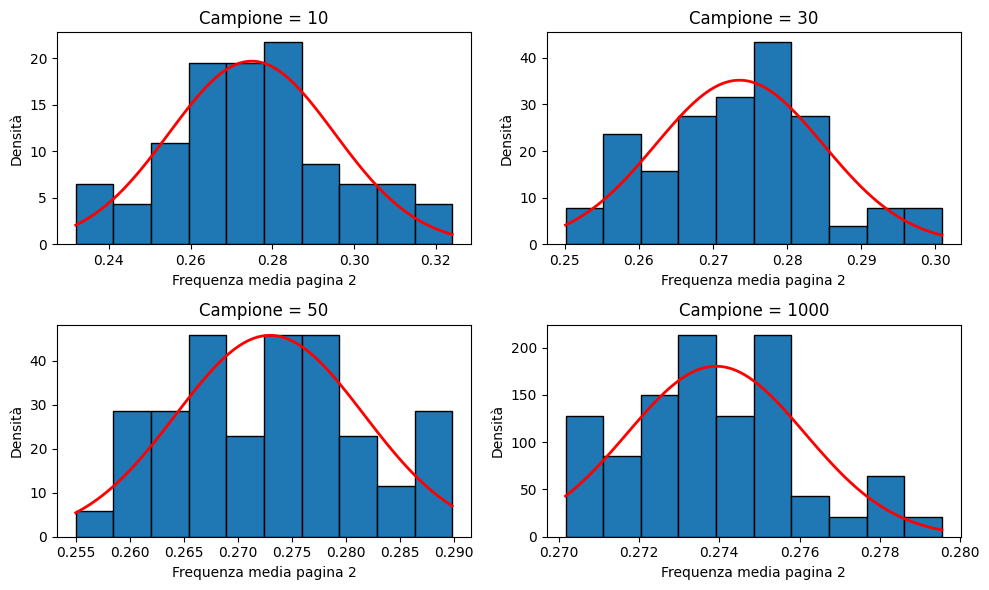

In [ ]:
import scipy.stats as spy

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
campioni = [10, 30, 50, 1000]

for ax, camp in zip(axes.flatten(), campioni):
    valori = frequenze_50(camp)

    ax.hist(valori, bins=10, edgecolor="black", density=True)  # density=True pour superposer la courbe

    # Courbe gaussienne
    mu = np.mean(valori)
    sigma = np.std(valori, ddof=1)
    x = np.linspace(min(valori), max(valori), 100)
    ax.plot(x, spy.norm.pdf(x, mu, sigma), color="red", linewidth=2)

    ax.set_title(f"Campione = {camp}")
    ax.set_xlabel("Frequenza media pagina 2")
    ax.set_ylabel("Densità")

plt.tight_layout()
plt.show()

#### 📊 Osservazione

All'aumentare della dimensione del campione, la distribuzione delle frequenze medie converge verso una **distribuzione normale**:

$$\bar{X}_N \xrightarrow{N \to \infty} \mathcal{N}\left(\mu,\, \frac{\sigma^2}{N}\right)$$

Questo conferma il **Teorema Limite Centrale**: indipendentemente dalla distribuzione originale, la media di N osservazioni indipendenti converge verso una gaussiana quando N è grande.

Questo si osserva chiaramente in due modi nei grafici:

1. **La media resta stabile** (~0.27) per tutti i valori di N, coerentemente con il fatto che $E[\bar{X}_N] = \mu$ per ogni N.
2. **La dispersione si riduce sistematicamente** all'aumentare di N: l'intervallo dei valori osservati si restringe di un fattore ≈10 passando da N=10 a N=1000, in linea con la legge teorica $\sigma_{\bar{X}} \propto 1/\sqrt{N}$ (poiché $\sqrt{1000/10} = \sqrt{100} = 10$).

Va notato che, con sole 50 ripetizioni per ciascun istogramma, la forma osservata non è perfettamente gaussiana — questo è dovuto al numero limitato di campioni nell'istogramma stesso, non a una violazione del teorema. La convergenza prevista dal TLC riguarda la distribuzione *teorica* di $\bar{X}_N$, che con un numero maggiore di ripetizioni risulterebbe visivamente più vicina a una curva normale liscia.

##**Estensioni 1**

In [ ]:
# Matrice di transizione modificata

P_modificata=np.array([
    [0,0.23,0,0.77,0,0],
    [0.09,0,0.06,0,0,0.85],
    [0,0,0,0.63,0,0.37],
    [0,0,0,0,0.65,0.35],
    [0,0,0,0,0,1],
    [0,0,0,0,1,0]
])

df=pd.DataFrame(P_modificata,index=[1,2,3,4,5,6],columns=[1,2,3,4,5,6])
df

,1,2,3,4,5,6
1,0.00,0.23,0.00,0.77,0.00,0.00
2,0.09,0.00,0.06,0.00,0.00,0.85
3,0.00,0.00,0.00,0.63,0.00,0.37
4,0.00,0.00,0.00,0.00,0.65,0.35
5,0.00,0.00,0.00,0.00,0.00,1.00
6,0.00,0.00,0.00,0.00,1.00,0.00


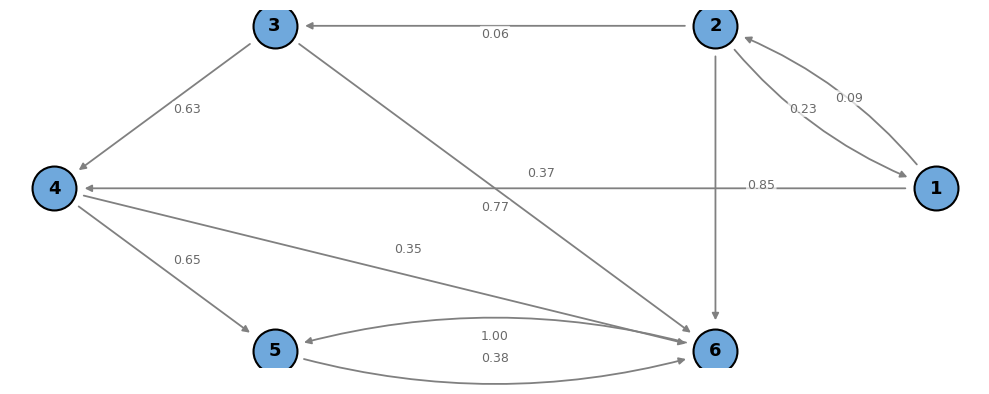

In [ ]:



n = P_modificata.shape[0]
labels = [str(i+1) for i in range(n)]

G = nx.DiGraph()
G.add_nodes_from(labels)
for i in range(n):
    for j in range(n):
        if P_modificata[i, j] > 0:
            G.add_edge(labels[i], labels[j], weight=P[i, j])

pos = nx.circular_layout(G)

fig, ax = plt.subplots(figsize=(10, 4))
nx.draw_networkx_nodes(G, pos, node_size=1000, node_color="#6FA8DC",
                        edgecolors="black", linewidths=1.5, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=13, font_weight="bold", ax=ax)

for u, v, d in G.edges(data=True):
    rad = 0.6 if u == v else (0.15 if (v, u) in G.edges else 0.0)
    ax.annotate("", xy=pos[v], xytext=pos[u],
                arrowprops=dict(arrowstyle="-|>", color="gray", lw=1.3,
                                 shrinkA=22, shrinkB=22,
                                 connectionstyle=f"arc3,rad={rad}"))

for u, v, d in G.edges(data=True):
    x, y = (pos[u][0]+pos[v][0])/2, (pos[u][1]+pos[v][1])/2
    dx, dy = pos[v][0]-pos[u][0], pos[v][1]-pos[u][1]
    offx, offy = -dy*0.06, dx*0.06
    ax.text(x+offx, y+offy, f"{d['weight']:.2f}", fontsize=9, ha="center",
            color="dimgray", bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="none", alpha=0.7))

#ax.set_title("Chaine de Markov modifiee : 6->2 supprime, 6->5=1.0")
ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
def indipendenza_partenza_vettorizzata(n_passo, Matrice):
    n_stati = Matrice.shape[0]
    stati_correnti = np.arange(n_stati)
    conteggi = np.zeros((n_stati, n_stati), dtype=int)

    for _ in range(n_passo):
        conteggi[np.arange(n_stati), stati_correnti] += 1
        cum = Matrice[stati_correnti].cumsum(axis=1)
        r = rng.random(n_stati)[:, None]
        stati_correnti = (cum > r).argmax(axis=1)

    frequenze_prob = conteggi / n_passo
    df = pd.DataFrame(
        frequenze_prob,
        columns=[f"Pagina {i+1}" for i in range(n_stati)],
        index=[f"Partenza da {i+1}" for i in range(n_stati)]
    )
    return df

print(indipendenza_partenza_vettorizzata(10001, P_modificata))

               Pagina 1  Pagina 2  Pagina 3  Pagina 4  Pagina 5  Pagina 6
Partenza da 1    0.0001    0.0001    0.0000    0.0000   0.49985   0.49995
Partenza da 2    0.0000    0.0001    0.0000    0.0000   0.49995   0.49995
Partenza da 3    0.0000    0.0000    0.0001    0.0001   0.49995   0.49985
Partenza da 4    0.0000    0.0000    0.0000    0.0001   0.49995   0.49995
Partenza da 5    0.0000    0.0000    0.0000    0.0000   0.50005   0.49995
Partenza da 6    0.0000    0.0000    0.0000    0.0000   0.49995   0.50005


### 📊 Spiegazione — Estensione 1

Con la modifica **6→5 = 1.0**, le pagine 5 e 6 formano un **ciclo chiuso obbligatorio**:
$$5 \to 6 \to 5 \to 6 \to \cdots$$
Non esiste nessun link che permette di uscire da questo ciclo verso le pagine 1, 2, 3 o 4.

Questo ha due conseguenze fondamentali:

**1. Le pagine 1, 2, 3, 4 diventano stati transienti.**
Ci si passa solo all'inizio della navigazione, poi si viene inevitabilmente assorbiti nel ciclo {5, 6}.
Tutte le traiettorie finiscono nel ciclo — qualunque sia la pagina di partenza.

**2. Il ciclo {5, 6} è periodico di periodo 2.**
Il comportamento è deterministico: se sei su 5, il passo successivo sei su 6, e viceversa.

$$\text{Partenza da 5:} \quad 5 \to 6 \to 5 \to 6 \to \cdots$$
$$\text{Partenza da 6:} \quad 6 \to 5 \to 6 \to 5 \to \cdots$$

La distribuzione **in un preciso istante** $n$ dipende quindi dalla pagina iniziale:
se $n$ è pari e si parte da 5, si è certamente su 5; se si parte da 6, si è su 6.

Le medie temporali mostrano 50/50 per tutti i punti di partenza, ma non catturano questo effetto.

> **Conclusione:** La catena perde **irriducibilità** (le pagine 1–4 non comunicano più con {5,6} in entrambe le direzioni) e **aperiodicità** (periodo 2). Senza queste proprietà, la catena non è più ergodica: la distribuzione istantanea dipende dalla pagina iniziale.

##Estensioni 2
modifica freccia da 6 a 3

In [ ]:
# Matrice di transizione modificata

P_modificata2=np.array([
   [0,0.23,0,0.77,0,0],
    [0.09,0,0.06,0,0,0.85],
    [0,0,0,0.63,0,0.37],
    [0,0,0,0,0.65,0.35],
    [0,0,0,0,0,1],
    [0,0,0.62,0,0.38,0]
])

df=pd.DataFrame(P_modificata2,index=[1,2,3,4,5,6],columns=[1,2,3,4,5,6])
df

,1,2,3,4,5,6
1,0.00,0.23,0.00,0.77,0.00,0.00
2,0.09,0.00,0.06,0.00,0.00,0.85
3,0.00,0.00,0.00,0.63,0.00,0.37
4,0.00,0.00,0.00,0.00,0.65,0.35
5,0.00,0.00,0.00,0.00,0.00,1.00
6,0.00,0.00,0.62,0.00,0.38,0.00


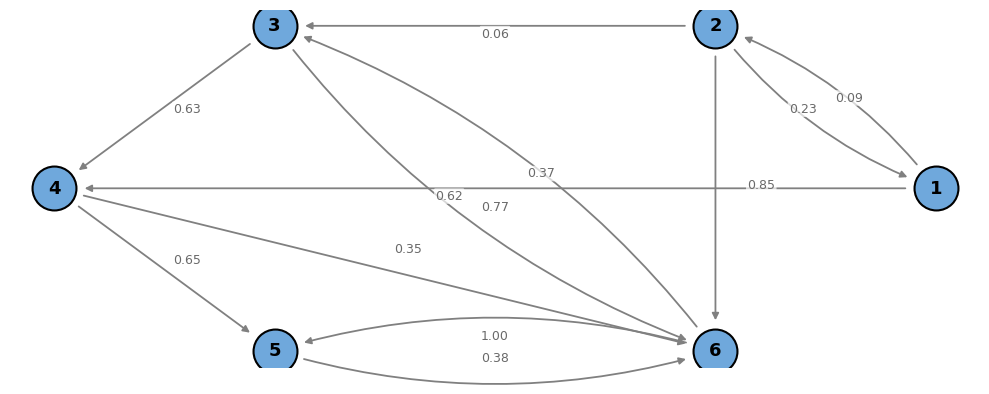

In [ ]:
n = P_modificata2.shape[0]
labels = [str(i+1) for i in range(n)]

G = nx.DiGraph()
G.add_nodes_from(labels)
for i in range(n):
    for j in range(n):
        if P_modificata2[i, j] > 0:          # <-- corrigé
            G.add_edge(labels[i], labels[j], weight=P_modificata2[i, j])  # <-- corrigé

pos = nx.circular_layout(G)

fig, ax = plt.subplots(figsize=(10, 4))
nx.draw_networkx_nodes(G, pos, node_size=1000, node_color="#6FA8DC",
                        edgecolors="black", linewidths=1.5, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=13, font_weight="bold", ax=ax)

for u, v, d in G.edges(data=True):
    rad = 0.6 if u == v else (0.15 if (v, u) in G.edges else 0.0)
    ax.annotate("", xy=pos[v], xytext=pos[u],
                arrowprops=dict(arrowstyle="-|>", color="gray", lw=1.3,
                                 shrinkA=22, shrinkB=22,
                                 connectionstyle=f"arc3,rad={rad}"))

for u, v, d in G.edges(data=True):
    x, y = (pos[u][0]+pos[v][0])/2, (pos[u][1]+pos[v][1])/2
    dx, dy = pos[v][0]-pos[u][0], pos[v][1]-pos[u][1]
    offx, offy = -dy*0.06, dx*0.06
    ax.text(x+offx, y+offy, f"{d['weight']:.2f}", fontsize=9, ha="center",
            color="dimgray", bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="none", alpha=0.7))

ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
print(indipendenza_partenza_vettorizzata(1000,P_modificata2))

               Pagina 1  Pagina 2  Pagina 3  Pagina 4  Pagina 5  Pagina 6
Partenza da 1     0.001     0.000     0.231     0.142     0.246     0.380
Partenza da 2     0.000     0.001     0.240     0.136     0.235     0.388
Partenza da 3     0.000     0.000     0.227     0.135     0.251     0.387
Partenza da 4     0.000     0.000     0.234     0.147     0.240     0.379
Partenza da 5     0.000     0.000     0.230     0.157     0.249     0.364
Partenza da 6     0.000     0.000     0.246     0.153     0.229     0.372


# Estensione 2 — Cosa si osserva e perché

## 📊 Cosa si osserva

- La **distribuzione converge ancora verso una distribuzione unica** (indipendente dalla pagina iniziale) ✅
- Ma la **distribuzione è completamente diversa** dall'originale:
  - La **pagina 3** passa da ~1.5% a ~**23%** di visite
  - Le **pagine 1 e 2** quasi **spariscono**

---

## 🧠 Il motivo — spiegazione semplice

### Nella catena originale
La **pagina 6** mandava il **62%** del suo traffico verso la **pagina 2**.  
Questo rendeva la pagina 2 molto visitata (**~28%**).

### Nella catena modificata
Quel **62%** va invece verso la **pagina 3**.

Questo ha **due effetti principali**:

---

### 1️⃣ Pagina 3 diventa molto più importante

- Riceve ora un **flusso enorme** da **pagina 6**, che è essa stessa molto visitata (**~45%**)
- È come se una pagina popolare aggiungesse improvvisamente un link verso pagina 3 — il suo traffico la **"trascina" verso l'alto**
- Questo è esattamente l'idea del **PageRank**:  
  > *"Una pagina è importante se le pagine che la linkano sono a loro volta importanti"*

---

### 2️⃣ Pagine 1 e 2 diventano quasi irraggiungibili

**Prima:**
- Pagina 2 riceveva traffico da:
  - **Pagina 6** (prob. 0.62)
  - **Pagina 1** (prob. 0.23)

**Ora:**
- Pagina 6 **non linka più** pagina 2
- L'unico modo per arrivare su **pagina 2** è passare da **pagina 1**
- Ma **pagina 1** si raggiunge solo da **pagina 2 stessa** (prob. 0.09)

> Le due pagine si **"alimentano" solo tra loro** con probabilità basse, quindi **quasi nessun utente le visita**.

---

## 🔑 Concetto chiave

Questa modifica illustra perfettamente il **principio di retroazione** delle catene di Markov:

> Modificare una transizione da una pagina molto visitata può **ridistribuire completamente** il traffico nel sistema, seguendo il flusso delle probabilità.

È esattamente ciò che accade nel **PageRank** di Google:  
- Un link da una pagina importante ha **molto più peso** di un link da una pagina poco visitata
- Il traffico segue i link come un flusso che si ridistribuisce in base alla struttura del grafo

---

## 📈 Riepilogo visivo

| Pagina | Prima | Dopo | Variazione |
|--------|-------|------|------------|
| 1      | ~?    | ⬇️   | Quasi scompare |
| 2      | ~28%  | ⬇️   | Quasi scompare |
| 3      | ~1.5% | ~23% | ⬆️ Forte aumento |

**Motivo principale:**  
Il flusso di **pagina 6 (~45%)** viene reindirizzato su **pagina 3**, trascinandola verso l'alto e lasciando indietro le pagine 1 e 2.